# **1. Business Understanding**

**Stakeholder:** Executive Leadership & Marketing (Retention) Team

**Context:** A Telecommunications company in its first year of operation.

##### **Business Problem:** 
In the highly competitive telecommunications sector, the cost of acquiring a new customer is significantly higher than the cost of retaining an existing one. With the data collected within their time of operation, the company is seeing "leaks" in its customer base but lacks a proactive system to identify at-risk users before they disconnect.

**Objective:** To develop a predictive machine learning model that identifies potential "churners" (customers likely to leave).

##### **Success Criteria (ROI-Driven):**

**High Recall:** The model must catch at least 80% of potential churners to allow for proactive intervention.

# **2. Data Understanding**

- The dataset used in this project can be accessed [here.](https://www.kaggle.com/datasets/becksddf/churn-in-telecoms-dataset)

- The dataset consists of customer activity records from the first year of operations. It contains a mix of demographic information, plan details, and usage metrics.

##### **Key Feature Descriptions**
- To ensure model stability and interpretability, the following features were identified as primary drivers:

|Feature Category | Key Variables | Business Relevance |
| :--- | :--- | :-- |
| Account Info |Account Length, State, Area Code | Helps identify if churn is related to tenure or specific regional service issues.|
| Plan Details | International Plan, Voice Mail Plan | Crucial for identifying if specific product bundles are causing friction or adding 'stickiness.' |
| Usage Metrics | Total Day/Eve/Night Charge, | Monetary behavior. High day-time spend is a known 'pain point' for budget-conscious users. |
| Service Touchpoints | Customer Service Calls | The 'Frustration Metric.' Direct evidence of a customer's dissatisfaction. |

##### **Data Quality & Preprocessing**
- **Target Imbalance:** The dataset is imbalanced (fewer people leave than stay), requiring cost-sensitive learning techniques.

| Class | Count | Percentage |
| :--- | :--- | :--- |
| Stayed (0) | 2,850 | ~85.5% |
| Left (1) | 483 | ~14.5% |

- **Multicollinearity:** "Minutes" and "Charge" columns were perfectly correlated ($r = 1.0$).
"Minutes" were dropped to focus on the financial impact of usage.

- **Scaling:** Continuous variables were scaled using StandardScaler to ensure the Logistic Regression coefficients are comparable and interpretable.

# **3. Data Preparation**

In [2]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression, RidgeClassifier, Lasso
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

## Basic Data Cleaning

In [3]:
# Load Dataset
df = pd.read_csv('../Data/customer_churn.csv')
df.head()


,state,account length,area code,phone number,international plan,voice mail plan,number vmail messages,total day minutes,total day calls,total day charge,...,total eve calls,total eve charge,total night minutes,total night calls,total night charge,total intl minutes,total intl calls,total intl charge,customer service calls,churn
0,KS,128,415,382-4657,no,yes,25,265.1,110,45.07,...,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,371-7191,no,yes,26,161.6,123,27.47,...,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,358-1921,no,no,0,243.4,114,41.38,...,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,375-9999,yes,no,0,299.4,71,50.90,...,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,330-6626,yes,no,0,166.7,113,28.34,...,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


In [4]:
df.columns

Index(['state', 'account length', 'area code', 'phone number',
       'international plan', 'voice mail plan', 'number vmail messages',
       'total day minutes', 'total day calls', 'total day charge',
       'total eve minutes', 'total eve calls', 'total eve charge',
       'total night minutes', 'total night calls', 'total night charge',
       'total intl minutes', 'total intl calls', 'total intl charge',
       'customer service calls', 'churn'],
      dtype='object')

In [27]:
df['churn'].value_counts(normalize=True) * 100

churn
False    85.508551
True     14.491449
Name: proportion, dtype: float64

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3333 entries, 0 to 3332
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   state                   3333 non-null   object 
 1   account length          3333 non-null   int64  
 2   area code               3333 non-null   int64  
 3   phone number            3333 non-null   object 
 4   international plan      3333 non-null   object 
 5   voice mail plan         3333 non-null   object 
 6   number vmail messages   3333 non-null   int64  
 7   total day minutes       3333 non-null   float64
 8   total day calls         3333 non-null   int64  
 9   total day charge        3333 non-null   float64
 10  total eve minutes       3333 non-null   float64
 11  total eve calls         3333 non-null   int64  
 12  total eve charge        3333 non-null   float64
 13  total night minutes     3333 non-null   float64
 14  total night calls       3333 non-null   

In [7]:
df.isnull().sum()

state                     0
account length            0
area code                 0
phone number              0
international plan        0
voice mail plan           0
number vmail messages     0
total day minutes         0
total day calls           0
total day charge          0
total eve minutes         0
total eve calls           0
total eve charge          0
total night minutes       0
total night calls         0
total night charge        0
total intl minutes        0
total intl calls          0
total intl charge         0
customer service calls    0
churn                     0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

- ##### There are 21 features and 3333 records with 0 nulls. Data has no duplicates.

## Data Preprocessing
- #### Split the data first to avoid data leakage risk.

In [9]:
# x and y
X = df.drop(['churn','phone number'], axis=1)
y = df['churn']

In [10]:
# train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [11]:
X_train.head()

,state,account length,area code,international plan,voice mail plan,number vmail messages,total day minutes,total day calls,total day charge,total eve minutes,total eve calls,total eve charge,total night minutes,total night calls,total night charge,total intl minutes,total intl calls,total intl charge,customer service calls
3286,OH,106,415,no,yes,30,220.1,105,37.42,222.2,109,18.89,158.4,96,7.13,13.1,8,3.54,0
86,IN,94,408,no,no,0,157.9,105,26.84,155.0,101,13.18,189.6,84,8.53,8.0,5,2.16,4
1349,KY,71,510,no,yes,22,141.4,107,24.04,163.0,105,13.86,220.0,99,9.90,5.6,3,1.51,2
1649,NH,130,408,no,no,0,68.4,86,11.63,193.3,110,16.43,171.5,139,7.72,10.4,4,2.81,0
3000,NJ,87,510,no,no,0,223.2,109,37.94,127.5,86,10.84,289.3,83,13.02,14.5,4,3.92,3


- ### Label encoding for y, one hot encoding for x categorical features, Scaling numerical features, target encoding for state feature:

In [12]:
# Encode target variable
le = LabelEncoder()
y_train_encoded = pd.DataFrame(le.fit_transform(y_train), columns=['churn'])
y_test_encoded = pd.DataFrame(le.transform(y_test), columns=['churn'])

# Encode categorical features(international plan,area code and voice mail plan)
categorical_features = ['international plan', 'voice mail plan', 'area code']
ohe = OneHotEncoder(drop='first', sparse_output=False)
X_train_encoded = pd.DataFrame(ohe.fit_transform(X_train[categorical_features]),
                                columns=ohe.get_feature_names_out(categorical_features))
X_test_encoded = pd.DataFrame(ohe.transform(X_test[categorical_features]), 
                              columns=ohe.get_feature_names_out(categorical_features))
# Drop original categorical features and concatenate encoded features
X_train_final = pd.concat([X_train.drop(categorical_features, axis=1).reset_index(drop=True),
                            X_train_encoded.reset_index(drop=True)], axis=1)
X_test_final = pd.concat([X_test.drop(categorical_features, axis=1).reset_index(drop=True),
                           X_test_encoded.reset_index(drop=True)], axis=1)

# Target encoding for state feature
state_churn_means = y_train.groupby(X_train_final['state']).mean()
state_dict = state_churn_means.to_dict()
X_train_final['state_encoded'] = X_train_final['state'].map(state_dict)
X_test_final['state_encoded'] = X_test_final['state'].map(state_dict)

# Drop the original 'state'
x_Train = X_train_final.drop('state', axis=1)
x_Test = X_test_final.drop('state', axis=1)

# Ensure both sets have similar columns order
x_Test = x_Test[x_Train.columns]

# Handle missing values in state_encoded by filling with global mean
global_mean = y_train_encoded['churn'].mean()
x_Train['state_encoded'] = x_Train['state_encoded'].fillna(global_mean)
x_Test['state_encoded'] = x_Test['state_encoded'].fillna(global_mean)

- ### Scaling using standard scaler

In [13]:
# Columns to scale
encoded_cols = list(X_train_encoded.columns) + ['state_encoded']
numerical_cols = [col for col in x_Train.columns if col not in encoded_cols]

# fit x_Train
scaler = StandardScaler()
scaler.fit(x_Train[numerical_cols])

# Transform x_train and x_test
x_train_num_scaled = pd.DataFrame(scaler.transform(x_Train[numerical_cols]), 
                                  columns=numerical_cols, index=x_Train.index)
x_test_num_scaled = pd.DataFrame(scaler.transform(x_Test[numerical_cols]), 
                                 columns=numerical_cols, index=x_Test.index)

# Concatenate with encoded features
x_train = pd.concat([x_train_num_scaled, x_Train[encoded_cols]], axis=1)
x_test = pd.concat([x_test_num_scaled, x_Test[encoded_cols]], axis=1)

# Ensure both sets have similar columns order
x_test = x_test[x_train.columns]

# Exploratory Data Analysis (EDA)
- #### x_train and y_train will be used for EDA

## 1. Multicollinearity check:
- ##### Use a correlation heatmap to see how features vary with each other.

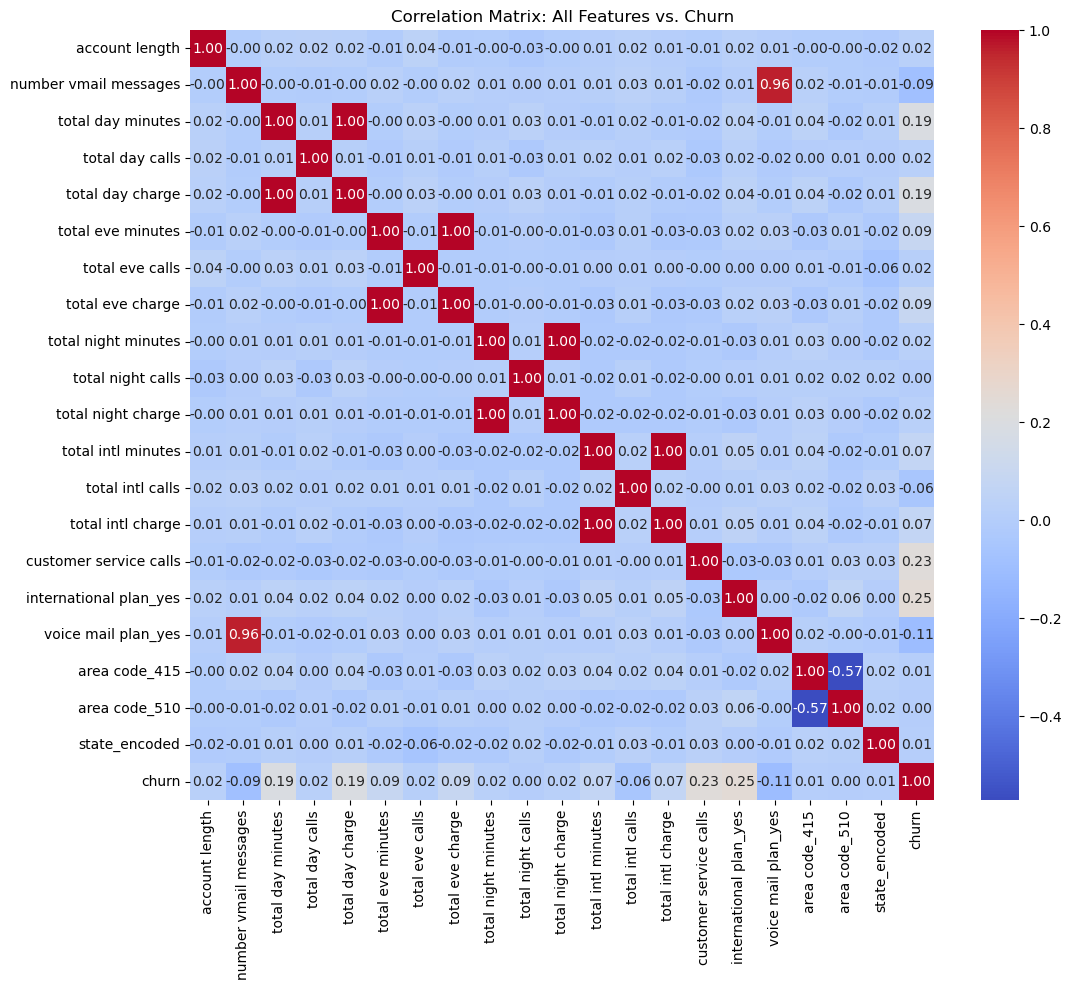

In [14]:
# Correlation matrix
plot_data = pd.concat([x_train, y_train_encoded], axis=1)

plt.figure(figsize=(12,10))
sns.heatmap(plot_data.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Matrix: All Features vs. Churn')
plt.show()

##### **Insight:**
- Generally, minutes and charges are perfectly correlated.
- This can be explained by how charge is calculated:$$\text{Charge} = \text{Rate} \times \text{Minutes}$$
- Minutes columns will be dropped before fitting the model.

# 2.What features contribute to churn rate?

### **How many service calls does it take for a customer to transition from 'satisfied' to 'at risk of leaving'?**

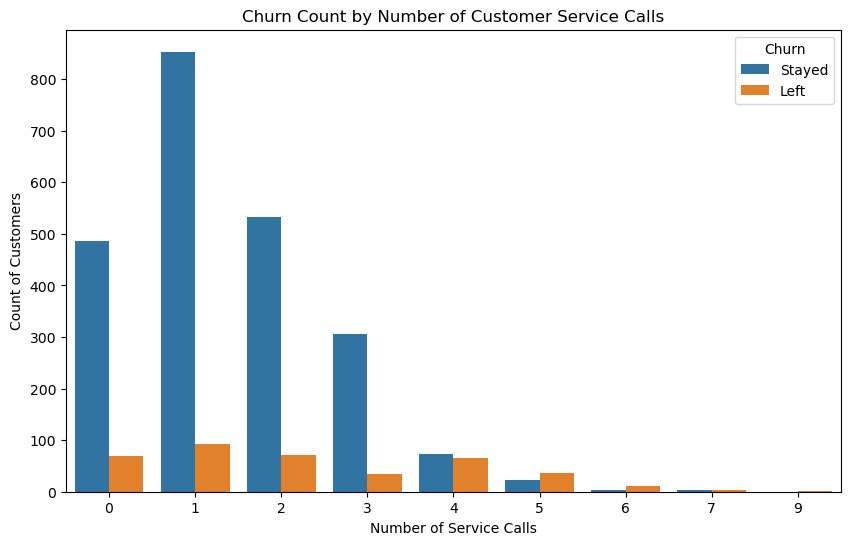

In [15]:
# plot customer service calls vs churn
plt.figure(figsize=(10, 6))
sns.countplot(data=X_train.assign(churn=y_train), x='customer service calls', hue='churn')
plt.title('Churn Count by Number of Customer Service Calls')
plt.xlabel('Number of Service Calls')
plt.ylabel('Count of Customers')
plt.legend(title='Churn', labels=['Stayed', 'Left'])
plt.show()

##### **Insights:**

- From service calls 0-3, customers are generally satisfied and the 'stayed' bar is significantly higher. 

- At service call 4, the 'stayed' and 'left' bars are almost level. Customers are at high risk of leaving after 3 service calls.

### **Does International Plan affect Churn Rate?**

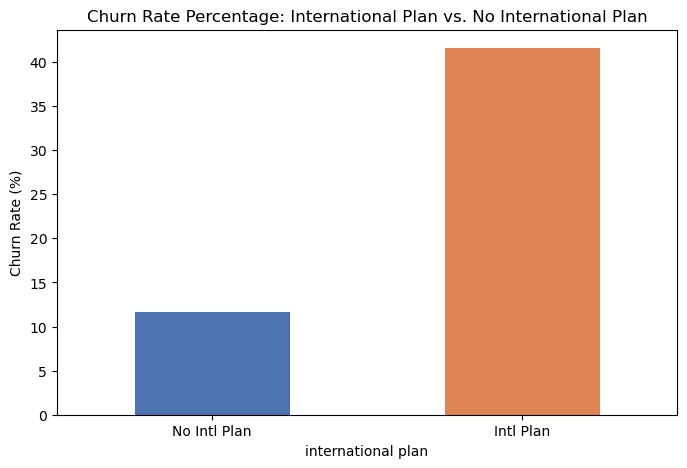

In [16]:
# Calculating churn rate percentage per plan type
plan_churn = X_train.assign(churn=y_train).groupby('international plan')['churn'].mean() * 100

plt.figure(figsize=(8, 5))
plan_churn.plot(kind='bar', color=['#4C72B0', '#DD8452'])
plt.title('Churn Rate Percentage: International Plan vs. No International Plan')
plt.ylabel('Churn Rate (%)')
plt.xticks(ticks=[0, 1], labels=['No Intl Plan', 'Intl Plan'], rotation=0)
plt.show()

##### **Insight:**
- Customers with international plans have significantly higher churn rate as compared to the ones without. This could be due to factors like international call charges, international call quality e.t.c 
##### Further analysis is needed.

### **Customers with International Plan have a significantly higher churn rate. Why?**

##### Filter out customers with International Plan and find out features that correlate highly with churn rate.

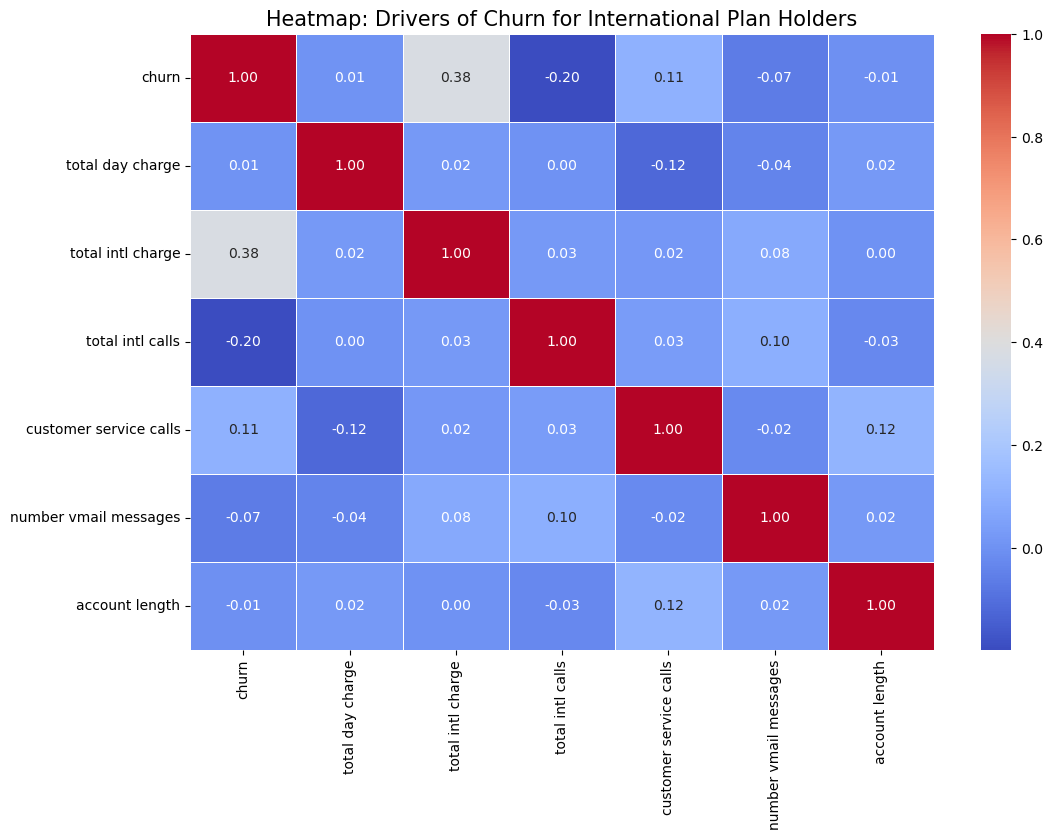

In [17]:
# Define the features we want to correlate against 'churn'
features_of_interest = [
    'churn', 'total day charge', 'total intl charge', 
    'total intl calls', 'customer service calls', 
    'number vmail messages', 'account length']
intl_segment = X_train[X_train['international plan'] == 'yes'].assign(churn=y_train)
corr_intl = intl_segment[features_of_interest].corr()

# plot heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr_intl, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Heatmap: Drivers of Churn for International Plan Holders', fontsize=15)
plt.show()

##### **Insight:**
- Churn and total international charge are positively(0.38) correlated. Customers percieve international call charges to be high. A higher charge increases the churning rate.

### **How do daily charges affect churn rate?**

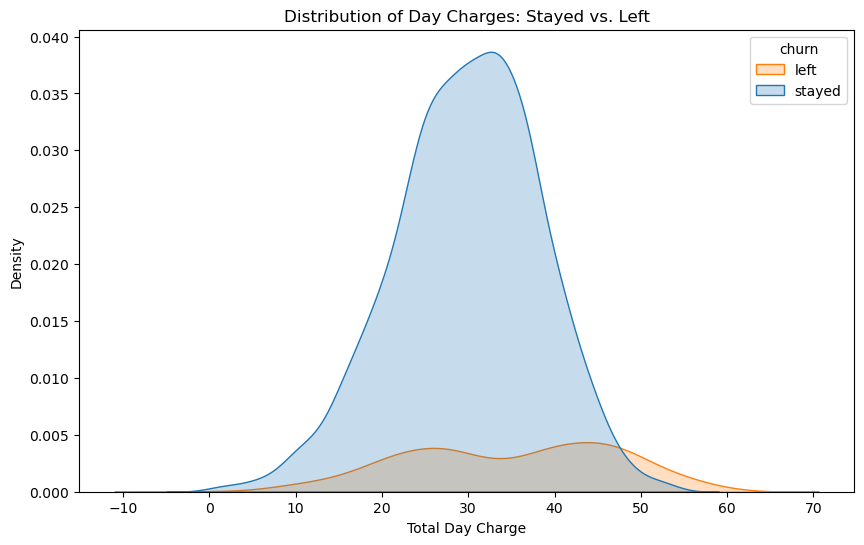

In [18]:
plt.figure(figsize=(10, 6))
sns.kdeplot(data=X_train.assign(churn=y_train), x='total day charge', hue='churn', fill=True,legend=False)
plt.title('Distribution of Day Charges: Stayed vs. Left')
plt.xlabel('Total Day Charge')
plt.legend(title = 'churn',labels = ['left','stayed'])
plt.show()

##### **Insights:**
- The 'left curve' (churn = True) has two peaks. 

- Cost at approximately 26 - Customers leave even when charges are low. This could be due to other factors like quality of service.

- Cost at approximately 48 - 'stay curve' (churn = False) almost disappears while 'left curve' (churn = False) remains visible.If a customer's daily charge exceeds 48, there is an overwhelming probability that they will leave. 

### **Churn rate peaked even at low charges. Why?**

##### Filter out customers whose daily charge < 30 and plot a correlation heat map to see features affecting churn rate.

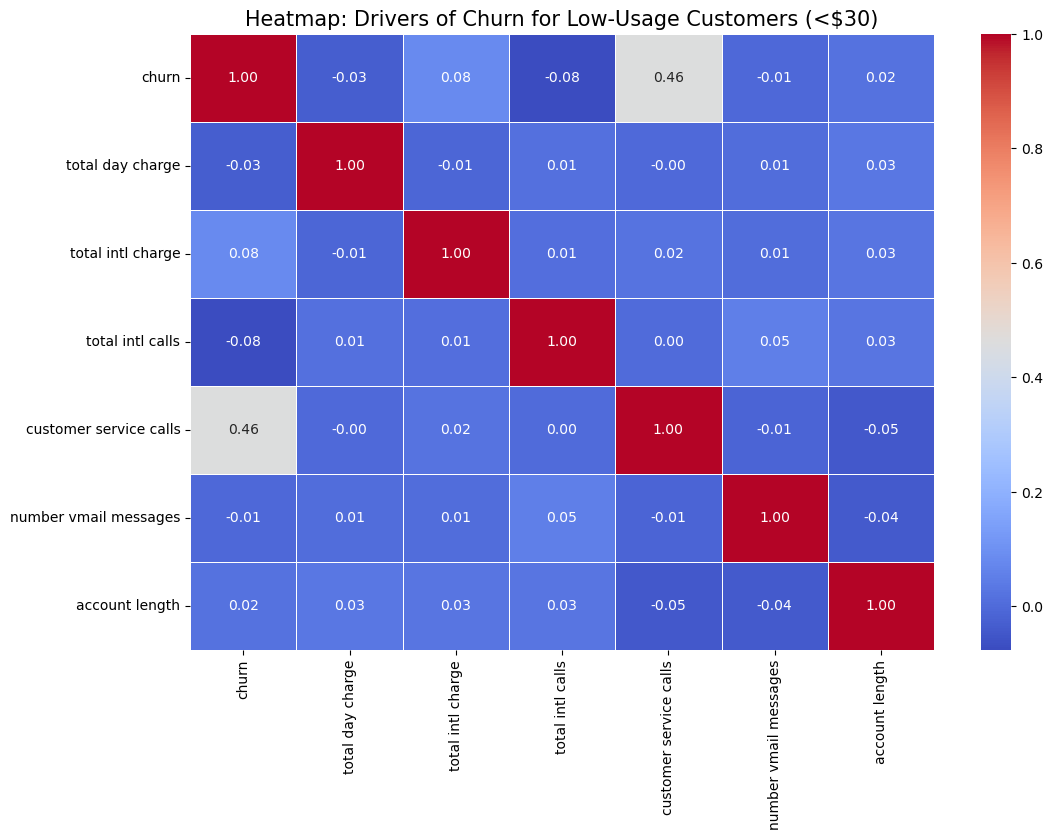

In [19]:
low_charge_segment = X_train[X_train['total day charge'] < 30].assign(churn=y_train)
corr_low = low_charge_segment[features_of_interest].corr()

# plot heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr_low, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Heatmap: Drivers of Churn for Low-Usage Customers (<$30)', fontsize=15)
plt.show()

##### **Insights**
- Churn correlates positively with customer service calls(0.46) and is higer than that of general population(0.23). Customers whose daily charge is <30 are leaving because of service quality.

### **Top 10 states Where churn rate peaked at low charges.**

In [20]:
# Map full statenames before plotting
state_map = {
    'AK': 'Alaska', 'AL': 'Alabama', 'AR': 'Arkansas', 'AZ': 'Arizona',
    'CA': 'California', 'CO': 'Colorado', 'CT': 'Connecticut', 'DC': 'District of Columbia',
    'DE': 'Delaware', 'FL': 'Florida', 'GA': 'Georgia', 'HI': 'Hawaii',
    'IA': 'Iowa', 'ID': 'Idaho', 'IL': 'Illinois', 'IN': 'Indiana',
    'KS': 'Kansas', 'KY': 'Kentucky', 'LA': 'Louisiana', 'MA': 'Massachusetts',
    'MD': 'Maryland', 'ME': 'Maine', 'MI': 'Michigan', 'MN': 'Minnesota',
    'MO': 'Missouri', 'MS': 'Mississippi', 'MT': 'Montana', 'NC': 'North Carolina',
    'ND': 'North Dakota', 'NE': 'Nebraska', 'NH': 'New Hampshire', 'NJ': 'New Jersey',
    'NM': 'New Mexico', 'NV': 'Nevada', 'NY': 'New York', 'OH': 'Ohio',
    'OK': 'Oklahoma', 'OR': 'Oregon', 'PA': 'Pennsylvania', 'RI': 'Rhode Island',
    'SC': 'South Carolina', 'SD': 'South Dakota', 'TN': 'Tennessee', 'TX': 'Texas',
    'UT': 'Utah', 'VA': 'Virginia', 'VT': 'Vermont', 'WA': 'Washington',
    'WI': 'Wisconsin', 'WV': 'West Virginia', 'WY': 'Wyoming'
}

# Apply state names to the plotting dataframe
plot_df = X_train.copy()
plot_df['state_full'] = df['state'].map(state_map)

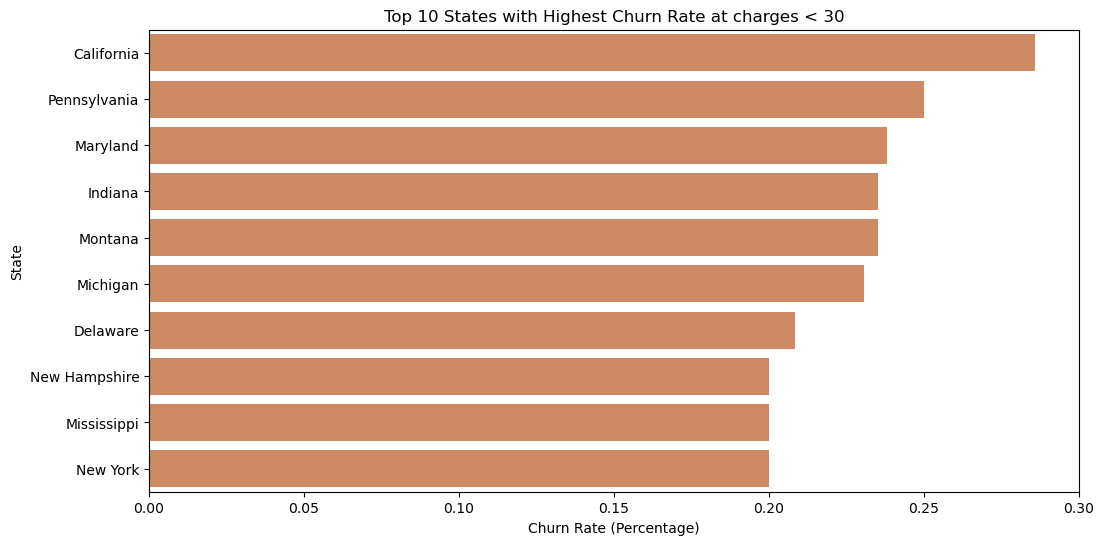

In [21]:
# Create a subset of low-usage customers
low_usage = plot_df[plot_df['total day charge'] < 30].copy()
low_usage['churn'] = y_train

# Plot the top 10 states with the highest churn rate for low-usage customers
low_usage_state_churn = low_usage.groupby('state_full')['churn'].mean().sort_values(ascending=False).head(10)
state_churn_report = low_usage.groupby('state_full')['churn'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=state_churn_report.values, y=state_churn_report.index,color='#DD8452')
plt.title('Top 10 States with Highest Churn Rate at charges < 30')
plt.xlabel('Churn Rate (Percentage)')
plt.ylabel('State')
plt.show()

##### **Insights:**
- In the above shown states, customers leave even at low daily charges. 
- These are most probably areas with poor network coverage for rural areas or urban service failure like signal interferance in high densuty areas.

# **4. Modeling**
## Saving preprocessed data to model in a new Notebook(churn_model)

In [22]:
# Save preprocessed data to use in the churn_model notebook
import os

target_path = os.path.join('..', 'Data', 'model_data')

os.makedirs(target_path, exist_ok=True)
  

# Save the files into that specific folder
x_train.to_csv(f'{target_path}/x_train_ready.csv', index=False)
x_test.to_csv(f'{target_path}/x_test_ready.csv', index=False)
y_train_encoded.to_csv(f'{target_path}/y_train_ready.csv', index=False)
y_test_encoded.to_csv(f'{target_path}/y_test_ready.csv', index=False)

In [23]:
# Save Standardscaler Object
import joblib

joblib.dump(scaler, f'{target_path}/scaler.joblib')

['../Data/model_data/scaler.joblib']

### Access the 'churn_model' notebook [here.](https://github.com/clivekinyanjui/Telecom-Customer-Retention/blob/main/Notebooks/churn_model.ipynb)